# 02a · Clustering — Foundations & Hierarchical Algorithm from Scratch

> **DS100 — Data Science Masterclass**  
> *Wear the hat of a technical expert **and** an intuitive teacher.*

---

## Road map

```
Part 0 — What is clustering?          (intuition + use-cases)
Part 1 — Euclidean distance           (the measurement engine)
Part 2 — Distance matrix              (all pairwise distances by hand)
Part 3 — Hierarchical clustering      (algorithm from first principles)
Part 4 — Dendrogram + flat clusters   (cutting the tree)
Part 5 — Linkage comparison           (single / complete / average)
```

**Rule**: the clustering algorithm itself uses only Python loops, `math`, and `numpy` — no scikit-learn.

---
## Part 0 — What is Clustering?

**Supervised learning** receives labelled examples and learns to predict labels for new data.

**Clustering (unsupervised)** receives *only* the data matrix — no labels — and discovers **natural groupings** in the data.

### Why does it work?

Points that are **close together** in feature space tend to share properties.  
Clustering exploits this structure — no ground-truth needed.

### Representative use-cases

| Domain | Task |
|--------|----- |
| Marketing | Group customers by purchasing behaviour |
| Biology | Discover gene expression patterns |
| NLP | Topic modelling, document grouping |
| Anomaly detection | Outliers = points far from every cluster |
| Image segmentation | Pixels with similar colour/texture |

### The central question: what does "close" mean?

Almost every clustering algorithm rests on a **distance function**.  
The most common choice — and our starting point — is the **Euclidean distance**.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({'font.size': 12, 'figure.dpi': 110})
np.random.seed(42)

print('Imports ready.')

Imports ready.


---
## Part 1 — Euclidean Distance

Given two points $\mathbf{p} = (p_1, p_2, \ldots, p_d)$ and $\mathbf{q} = (q_1, q_2, \ldots, q_d)$ in $d$-dimensional space:

$$
d(\mathbf{p}, \mathbf{q}) = \sqrt{\sum_{i=1}^{d}(p_i - q_i)^2}
$$

**In 2D** this reduces to the familiar ruler distance:
$$d(\mathbf{p}, \mathbf{q}) = \sqrt{(p_1 - q_1)^2 + (p_2 - q_2)^2}$$

### Metric properties (all three must hold for a valid distance)

| Property | Statement | Implication |
|----------|-----------|-------------|
| Non-negativity | $d(p,q) \geq 0$; $d(p,p)=0$ | Distance is never negative; zero only for identical points |
| Symmetry | $d(p,q) = d(q,p)$ | Distance doesn't depend on direction |
| Triangle inequality | $d(p,r) \leq d(p,q) + d(q,r)$ | No shortcut is longer than going via a third point |

These properties underpin clustering guarantees — without them, "closest cluster" becomes ill-defined.

### Other distance functions (for reference)

| Name | Formula | When to use |
|------|---------|-------------|
| Manhattan ($\ell_1$) | $\sum_i |p_i - q_i|$ | Sparse data, outlier robustness |
| Chebyshev ($\ell_\infty$) | $\max_i |p_i - q_i|$ | Grid-based movement |
| Cosine similarity | $1 - \frac{\mathbf{p}\cdot\mathbf{q}}{\|\mathbf{p}\|\|\mathbf{q}\|}$ | Text / direction matters more than magnitude |

--- 2D example ---
d(A, B)  = sqrt((1.0-4.0)^2 + (2.0-6.0)^2)
        = sqrt(9 + 16)
        = 5.0000   (3-4-5 right triangle: hypotenuse = 5) ✓

d(A, C)  = 0.0000   (identical points → zero) ✓

--- 4D example ---
d(P, Q) = 8.0000   (same formula, more terms)

Matches np.linalg.norm ✓


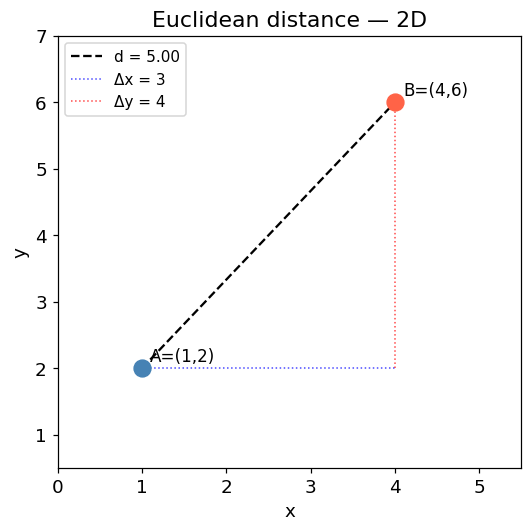

In [2]:
# ---- Euclidean distance from scratch — just a loop ----

def euclidean(p, q):
    """Euclidean distance between two iterables p and q."""
    return math.sqrt(sum((a - b) ** 2 for a, b in zip(p, q)))


# ----- Step-by-step worked example -----
A = [1.0, 2.0]
B = [4.0, 6.0]   # classic 3-4-5 right triangle
C = [1.0, 2.0]   # identical to A

print('--- 2D example ---')
print(f'd(A, B)  = sqrt(({A[0]}-{B[0]})^2 + ({A[1]}-{B[1]})^2)')
print(f'        = sqrt({(A[0]-B[0])**2:.0f} + {(A[1]-B[1])**2:.0f})')
print(f'        = {euclidean(A, B):.4f}   (3-4-5 right triangle: hypotenuse = 5) ✓')
print()
print(f'd(A, C)  = {euclidean(A, C):.4f}   (identical points → zero) ✓')

print('\n--- 4D example ---')
P = [1, 2, 3, 4]
Q = [5, 6, 7, 8]
print(f'd(P, Q) = {euclidean(P, Q):.4f}   (same formula, more terms)')

# Sanity-check against numpy
assert abs(euclidean(A, B) - float(np.linalg.norm(np.array(A) - np.array(B)))) < 1e-10
print('\nMatches np.linalg.norm ✓')

# ---- Visualise the 2D case ----
fig, ax = plt.subplots(figsize=(5, 5))
for pt, label, col in [(A, 'A=(1,2)', 'steelblue'), (B, 'B=(4,6)', 'tomato')]:
    ax.scatter(*pt, s=120, color=col, zorder=5)
    ax.annotate(label, (pt[0] + 0.1, pt[1] + 0.1), fontsize=11)
ax.plot([A[0], B[0]], [A[1], B[1]], 'k--', lw=1.5, label=f'd = {euclidean(A,B):.2f}')
ax.plot([A[0], B[0]], [A[1], A[1]], 'b:', lw=1, alpha=0.7, label='Δx = 3')
ax.plot([B[0], B[0]], [A[1], B[1]], 'r:', lw=1, alpha=0.7, label='Δy = 4')
ax.set_xlim(0, 5.5); ax.set_ylim(0.5, 7)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Euclidean distance — 2D')
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

---
## Part 2 — Distance Matrix

With $n$ data points we compute **all pairwise distances** and store them in an $n \times n$ symmetric matrix $\mathbf{D}$:

$$D_{ij} = d(\mathbf{x}_i, \mathbf{x}_j)$$

- Diagonal: $D_{ii} = 0$ (every point is at distance 0 from itself).
- Symmetric: $D_{ij} = D_{ji}$ (only the upper triangle needs computing).
- Total unique distances: $\binom{n}{2} = \frac{n(n-1)}{2}$

The distance matrix is the foundation of hierarchical clustering — it encodes the full geometry of the dataset.

Distance matrix (rounded to 2 dp):
[[0.   1.12 1.12 6.4  6.36 7.43]
 [1.12 0.   0.71 5.32 5.32 6.36]
 [1.12 0.71 0.   5.41 5.32 6.4 ]
 [6.4  5.32 5.41 0.   0.71 1.12]
 [6.36 5.32 5.32 0.71 0.   1.12]
 [7.43 6.36 6.4  1.12 1.12 0.  ]]

Smallest non-zero distance: 0.7071  (points [1 2])
Largest distance:           7.4330  (points [0 5])


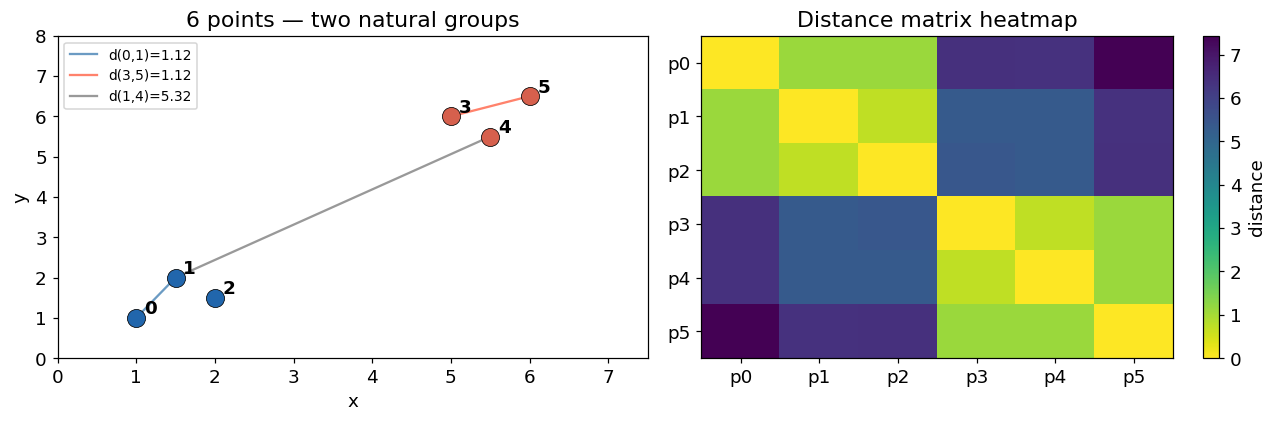

In [3]:
# ---- Build distance matrix with plain loops ----

def build_distance_matrix(X):
    """Return n×n numpy array of pairwise Euclidean distances."""
    n = len(X)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):   # upper triangle only
            d = euclidean(X[i], X[j])
            D[i, j] = d
            D[j, i] = d             # symmetric
    return D


# Small dataset: 6 points in 2D (manually chosen to form 2 loose groups)
points = np.array([
    [1.0, 1.0],   # 0 ─┐
    [1.5, 2.0],   # 1  ├─ group A (bottom-left)
    [2.0, 1.5],   # 2 ─┘
    [5.0, 6.0],   # 3 ─┐
    [5.5, 5.5],   # 4  ├─ group B (top-right)
    [6.0, 6.5],   # 5 ─┘
])

D = build_distance_matrix(points)

print('Distance matrix (rounded to 2 dp):')
print(np.round(D, 2))
print(f'\nSmallest non-zero distance: {D[D > 0].min():.4f}  (points {np.argwhere(D == D[D>0].min())[0]})')
print(f'Largest distance:           {D.max():.4f}  (points {np.argwhere(D == D.max())[0]})')

# ---- Visualise ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
colours = ['#2166ac'] * 3 + ['#d6604d'] * 3
for i, (x, y) in enumerate(points):
    ax.scatter(x, y, s=140, color=colours[i], zorder=3, edgecolors='k', lw=0.5)
    ax.annotate(str(i), (x + 0.1, y + 0.1), fontsize=12, fontweight='bold')
for (i, j), col, label in [((0, 1), 'steelblue', f'd(0,1)={D[0,1]:.2f}'),
                             ((3, 5), 'tomato',    f'd(3,5)={D[3,5]:.2f}'),
                             ((1, 4), 'grey',       f'd(1,4)={D[1,4]:.2f}')]:
    ax.plot([points[i,0], points[j,0]], [points[i,1], points[j,1]],
            '-', color=col, lw=1.5, alpha=0.8, label=label)
ax.set_title('6 points — two natural groups')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(fontsize=9); ax.set_xlim(0, 7.5); ax.set_ylim(0, 8)

ax = axes[1]
im = ax.imshow(D, cmap='viridis_r', aspect='auto')
plt.colorbar(im, ax=ax, label='distance')
ax.set_title('Distance matrix heatmap')
ax.set_xticks(range(6)); ax.set_yticks(range(6))
ax.set_xticklabels([f'p{i}' for i in range(6)])
ax.set_yticklabels([f'p{i}' for i in range(6)])

plt.tight_layout(); plt.show()

---
## Part 3 — Hierarchical Agglomerative Clustering

### Core idea

Start with $n$ singleton clusters — every point is its own cluster.  
Repeatedly **merge the two closest clusters** until a single cluster remains.  
Record every merge: the resulting tree is the **dendrogram**.  
Cut the tree at any height to obtain $k$ flat clusters.

### Algorithm (plain English)

```
Initialise:  clusters = { {0}, {1}, ..., {n-1} }
Repeat:
    (ci, cj) ← find the pair of clusters with smallest distance
    new_cluster ← merge ci and cj
    update all distances from new_cluster to remaining clusters
    remove ci and cj; add new_cluster
Until:  only 1 cluster remains
```

### Linkage — how to measure inter-cluster distance

| Linkage | $d(A, B)$ | Shape tendency |
|---------|-----------|----------------|
| **Single** | $\min_{a \in A, b \in B} d(a,b)$ | Elongated chains (chaining effect) |
| **Complete** | $\max_{a \in A, b \in B} d(a,b)$ | Compact, roughly equal-sized |
| **Average (UPGMA)** | $\frac{n_A \cdot d(A,k) + n_B \cdot d(B,k)}{n_A + n_B}$ | Good balance — robust default |

*UPGMA = Unweighted Pair Group Method with Arithmetic Mean*

### Complexity

| Step | Cost |
|------|------|
| Build distance matrix | $O(n^2)$ |
| $n-1$ merge iterations, each scanning $O(n^2)$ pairs | $O(n^3)$ total |
| Memory | $O(n^2)$ for the distance matrix |

Naive implementation works well up to $n \approx 5{,}000$; beyond that use optimised libraries.

In [4]:
# ============================================================
# Helper functions — pure Python loops, no sklearn
# ============================================================

def build_dist_dict(X):
    """Pairwise distances as a dict-of-dicts {i: {j: dist}}.
    Using a dict allows us to add new cluster IDs dynamically.
    """
    n = len(X)
    d = {i: {} for i in range(n)}
    for i in range(n):
        for j in range(i + 1, n):
            val = euclidean(X[i], X[j])
            d[i][j] = val
            d[j][i] = val
    return d


def find_closest_pair(d, active):
    """Scan all active cluster pairs; return (ci, cj, distance) for the closest."""
    best = float('inf')
    ci, cj = -1, -1
    active_list = sorted(active)
    for a in range(len(active_list)):
        for b in range(a + 1, len(active_list)):
            ii, jj = active_list[a], active_list[b]
            val = d[ii][jj]
            if val < best:
                best = val
                ci, cj = ii, jj
    return ci, cj, best


def update_distances(d, new_id, ci, cj, active, sizes, linkage):
    """Add new_id to the distance dict using the chosen linkage rule;
    then remove the two merged clusters ci and cj.
    """
    d[new_id] = {}
    for k in active:
        if k == ci or k == cj:
            continue
        if linkage == 'single':
            val = min(d[ci][k], d[cj][k])
        elif linkage == 'complete':
            val = max(d[ci][k], d[cj][k])
        else:  # 'average' — UPGMA weighted by cluster sizes
            ni, nj = sizes[ci], sizes[cj]
            val = (ni * d[ci][k] + nj * d[cj][k]) / (ni + nj)
        d[new_id][k] = val
        d[k][new_id] = val
    # Strip merged clusters from every row, then remove their rows
    for k in list(d.keys()):
        d[k].pop(ci, None)
        d[k].pop(cj, None)
    del d[ci], d[cj]

print('Helper functions defined.')

Helper functions defined.


In [5]:
# ============================================================
# AgglomerativeClustering — from first principles
# ============================================================

class AgglomerativeClustering:
    """
    Hierarchical agglomerative clustering from scratch.

    Parameters
    ----------
    linkage : 'single' | 'complete' | 'average'
    """

    def __init__(self, linkage='average'):
        self.linkage = linkage
        self.merge_history_  = []   # (ci, cj, dist, new_id) per step
        self.linkage_matrix_ = []   # scipy-compatible rows [ci, cj, dist, n_leaves]

    # ----------------------------------------------------------
    def fit(self, X):
        X = [list(row) for row in X]    # plain Python lists
        n = len(X)

        d          = build_dist_dict(X)
        active     = set(range(n))
        sizes      = {i: 1 for i in range(n)}
        membership = {i: {i} for i in range(n)}
        next_id    = n

        while len(active) > 1:
            ci, cj, dist_val = find_closest_pair(d, active)

            new_id = next_id
            next_id += 1

            sizes[new_id]      = sizes[ci] + sizes[cj]
            membership[new_id] = membership[ci] | membership[cj]

            self.merge_history_.append((ci, cj, dist_val, new_id))
            self.linkage_matrix_.append([
                float(ci), float(cj), dist_val, float(sizes[new_id])
            ])

            update_distances(d, new_id, ci, cj, active, sizes, self.linkage)
            active.discard(ci)
            active.discard(cj)
            active.add(new_id)

        self._membership = membership
        self._n = n
        return self

    # ----------------------------------------------------------
    def get_labels(self, n_clusters):
        """Cut the dendrogram to get n_clusters flat label assignments."""
        n = self._n
        active     = set(range(n))
        membership = {i: {i} for i in range(n)}
        n_merges   = n - n_clusters     # perform exactly this many merges

        for step, (ci, cj, _, new_id) in enumerate(self.merge_history_):
            if step >= n_merges:
                break
            membership[new_id] = membership[ci] | membership[cj]
            active.discard(ci)
            active.discard(cj)
            active.add(new_id)

        labels = np.zeros(n, dtype=int)
        for lbl, cid in enumerate(sorted(active)):
            for pt in membership[cid]:
                labels[pt] = lbl
        return labels

print('AgglomerativeClustering class ready.')

AgglomerativeClustering class ready.


In [6]:
# ============================================================
# Demo on the 6-point dataset — print every merge step
# ============================================================

hc6 = AgglomerativeClustering(linkage='single').fit(points)

print('Single-linkage merge history on 6 points')
print(f'{"Step":<6} {"Cluster A":<12} {"Cluster B":<12} {"Distance":<12} {"New ID"}')
print('-' * 54)
for step, (ci, cj, d_val, new_id) in enumerate(hc6.merge_history_):
    print(f'{step:<6} {ci:<12} {cj:<12} {d_val:<12.4f} {new_id}')

Single-linkage merge history on 6 points
Step   Cluster A    Cluster B    Distance     New ID
------------------------------------------------------
0      1            2            0.7071       6
1      3            4            0.7071       7
2      0            6            1.1180       8
3      5            7            1.1180       9
4      8            9            5.3151       10


---
## Part 4 — Dendrogram (from Scratch)

A **dendrogram** is a binary tree diagram where:
- **Leaves** (bottom) = individual points
- **Height of each junction** = distance at which two clusters merged
- **Horizontal cuts** at a given height give flat cluster assignments

To draw it from our `merge_history`, we track the x-position and current height of every cluster ID and draw the connecting lines with matplotlib — no scipy needed.

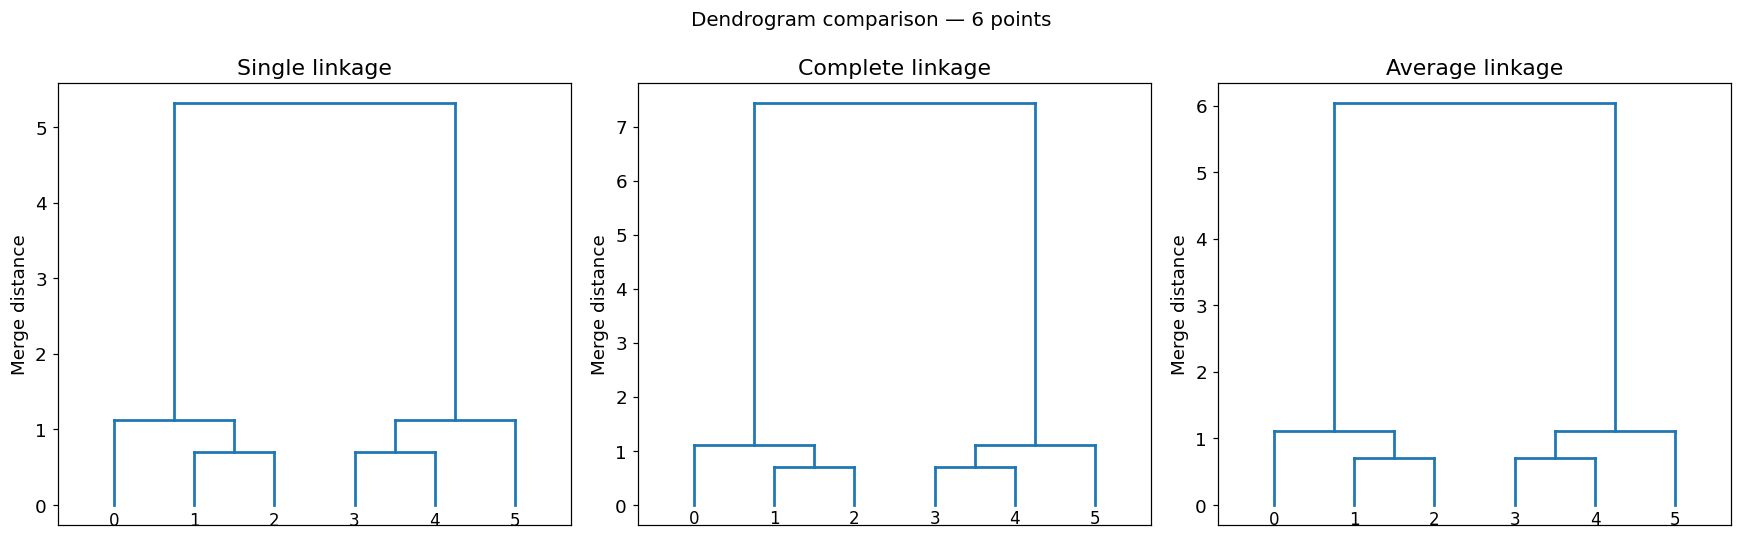

In [7]:
# ============================================================
# Draw a dendrogram directly from merge_history
# ============================================================

def draw_dendrogram(merge_history, n_points, ax=None, title='Dendrogram',
                    cut_height=None):
    """
    Draw a dendrogram from a list of (ci, cj, dist, new_id) tuples.
    Uses only matplotlib — no scipy.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))

    # Track the x-position and current top-height of every cluster
    x_pos = {i: float(i) for i in range(n_points)}
    y_pos = {i: 0.0      for i in range(n_points)}

    for ci, cj, dist_val, new_id in merge_history:
        xl, xr = x_pos[ci], x_pos[cj]
        yl, yr = y_pos[ci], y_pos[cj]

        colour = '#1f77b4'
        ax.plot([xl, xl], [yl, dist_val], '-', color=colour, lw=1.8)
        ax.plot([xr, xr], [yr, dist_val], '-', color=colour, lw=1.8)
        ax.plot([xl, xr], [dist_val, dist_val], '-', color=colour, lw=1.8)

        x_pos[new_id] = (xl + xr) / 2
        y_pos[new_id] = dist_val

    # Leaf labels
    for i in range(n_points):
        ax.text(x_pos[i], -0.08, str(i), ha='center', va='top', fontsize=11)

    if cut_height is not None:
        ax.axhline(cut_height, color='tomato', ls='--', lw=1.5,
                   label=f'cut at {cut_height:.2f}')
        ax.legend(fontsize=9)

    ax.set_xlim(-0.7, n_points - 0.3)
    ax.set_ylabel('Merge distance')
    ax.set_title(title)
    ax.tick_params(axis='x', bottom=False, labelbottom=False)
    return ax


# --- Draw for all three linkages on the 6-point dataset ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, lnk in zip(axes, ['single', 'complete', 'average']):
    hc_tmp = AgglomerativeClustering(linkage=lnk).fit(points)
    draw_dendrogram(hc_tmp.merge_history_, len(points), ax=ax,
                    title=f'{lnk.capitalize()} linkage')

plt.suptitle('Dendrogram comparison — 6 points', fontsize=13)
plt.tight_layout()
plt.show()

k=2  labels: [0 0 0 1 1 1]
k=3  labels: [2 2 2 1 1 0]
k=4  labels: [0 2 2 3 3 1]


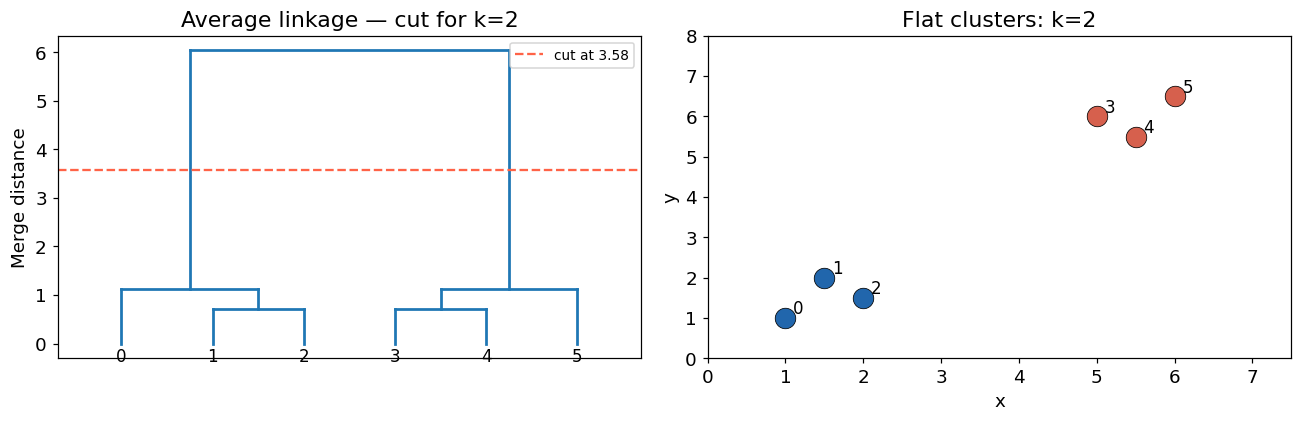

In [8]:
# ============================================================
# Cutting the dendrogram → flat cluster labels
# ============================================================

hc6_avg = AgglomerativeClustering(linkage='average').fit(points)

for k in [2, 3, 4]:
    lbs = hc6_avg.get_labels(k)
    print(f'k={k}  labels: {lbs}')

# Show k=2 graphically with a cut line
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
# Find the merge distance that produces k=2 clusters (i.e., the last-but-one merge distance)
merge_dists = [mh[2] for mh in hc6_avg.merge_history_]
cut = (merge_dists[-1] + merge_dists[-2]) / 2  # midpoint between last two merges
draw_dendrogram(hc6_avg.merge_history_, len(points), ax=ax,
                title='Average linkage — cut for k=2', cut_height=cut)

ax = axes[1]
lbs2 = hc6_avg.get_labels(2)
colour_map = ['#2166ac', '#d6604d']
for i, (x, y) in enumerate(points):
    ax.scatter(x, y, s=180, color=colour_map[lbs2[i]], edgecolors='k', lw=0.5, zorder=3)
    ax.annotate(str(i), (x + 0.1, y + 0.1), fontsize=11)
ax.set_title('Flat clusters: k=2')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_xlim(0, 7.5); ax.set_ylim(0, 8)

plt.tight_layout(); plt.show()

---
## Part 5 — Linkage Comparison on a Realistic Dataset

Three Gaussian blobs: 90 points total, 30 per cluster.  
Generated with NumPy only — no `make_blobs`.

Dataset: 90 points  |  3 true clusters  |  std=0.9


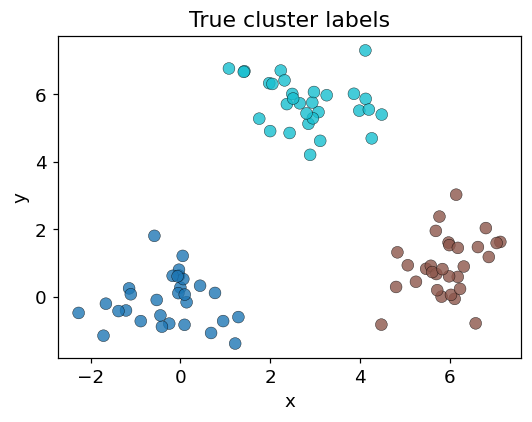

In [9]:
# ============================================================
# Generate a 3-cluster dataset from scratch (no sklearn)
# ============================================================

rng = np.random.default_rng(7)

centres   = np.array([[0.0, 0.0], [6.0, 1.0], [3.0, 6.0]])
std       = 0.9
n_per     = 30

X_data = np.vstack([
    rng.normal(loc=c, scale=std, size=(n_per, 2))
    for c in centres
])
true_labels = np.repeat([0, 1, 2], n_per)

print(f'Dataset: {len(X_data)} points  |  3 true clusters  |  std={std}')

# Quick plot
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(X_data[:, 0], X_data[:, 1], c=true_labels, cmap='tab10',
           alpha=0.8, edgecolors='k', lw=0.3, s=60)
ax.set_title('True cluster labels'); ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout(); plt.show()

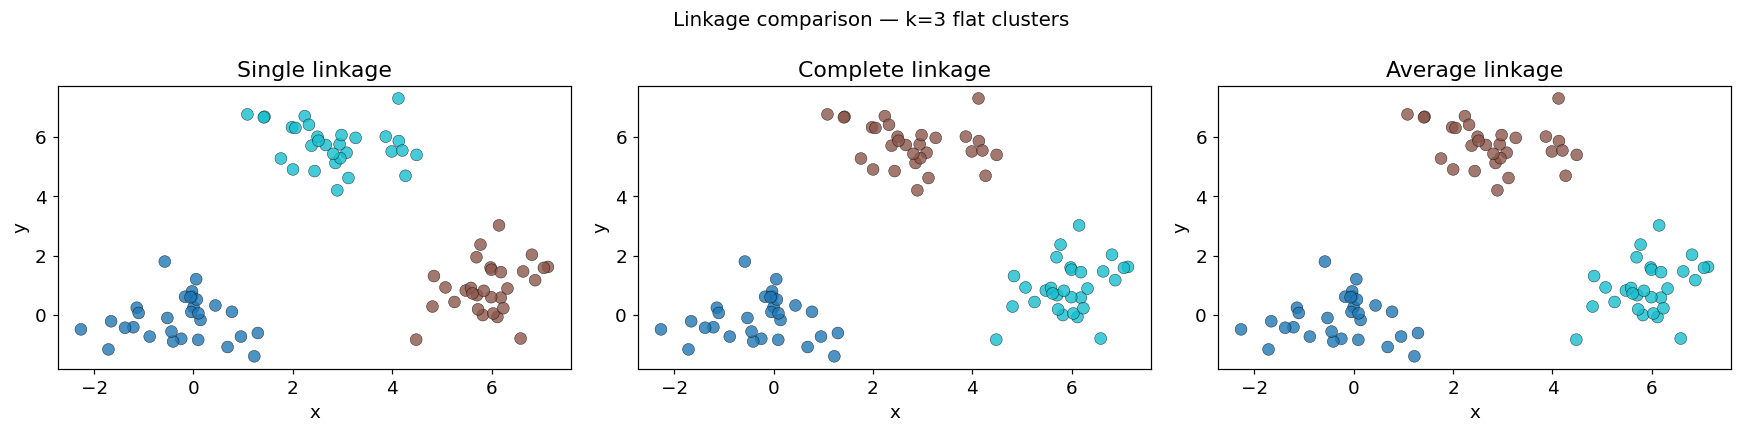

Take-aways:
  Single   → prone to chaining (one outlier can bridge groups)
  Complete → compact clusters, but may fracture elongated blobs
  Average  → good balance; typically the best default


In [10]:
# ============================================================
# Fit all three linkages and compare
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, lnk in zip(axes, ['single', 'complete', 'average']):
    hc_tmp = AgglomerativeClustering(linkage=lnk).fit(X_data)
    preds  = hc_tmp.get_labels(n_clusters=3)
    ax.scatter(X_data[:, 0], X_data[:, 1], c=preds, cmap='tab10',
               alpha=0.8, edgecolors='k', lw=0.3, s=60)
    ax.set_title(f'{lnk.capitalize()} linkage')
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.suptitle('Linkage comparison — k=3 flat clusters', fontsize=13)
plt.tight_layout()
plt.show()

print('Take-aways:')
print('  Single   → prone to chaining (one outlier can bridge groups)')
print('  Complete → compact clusters, but may fracture elongated blobs')
print('  Average  → good balance; typically the best default')

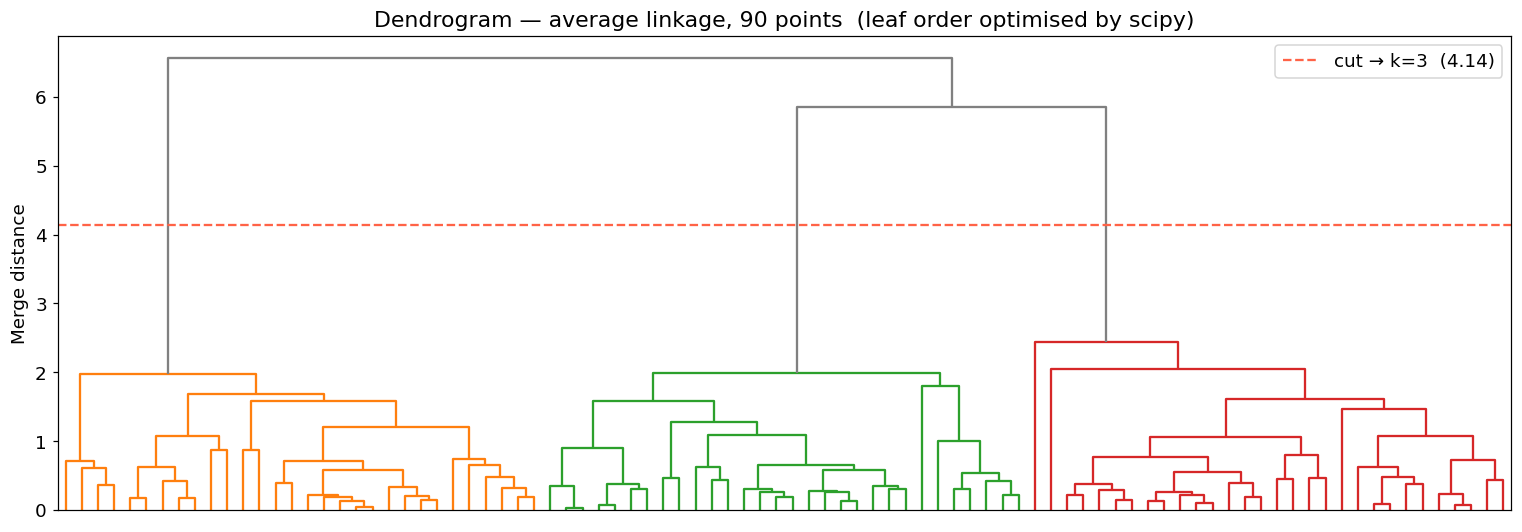

In [11]:
# ============================================================
# Dendrogram on the larger dataset using scipy for layout
# (algorithm is still ours — we just pass our linkage matrix to scipy
#  for the leaf-reordering optimisation that makes large dendrograms readable)
# ============================================================

from scipy.cluster.hierarchy import dendrogram as scipy_dendrogram

hc_avg = AgglomerativeClustering(linkage='average').fit(X_data)
Z = np.array(hc_avg.linkage_matrix_)   # our own merge records

fig, ax = plt.subplots(figsize=(14, 5))
scipy_dendrogram(Z, ax=ax, color_threshold=0.6 * Z[:, 2].max(),
                 above_threshold_color='grey', no_labels=True)
ax.set_title('Dendrogram — average linkage, 90 points  (leaf order optimised by scipy)')
ax.set_ylabel('Merge distance')
# Mark the cut for k=3
cut3 = (Z[-2, 2] + Z[-3, 2]) / 2
ax.axhline(cut3, color='tomato', ls='--', lw=1.5, label=f'cut → k=3  ({cut3:.2f})')
ax.legend()
plt.tight_layout(); plt.show()

---
## Summary

### What we built from scratch

| Component | Role |
|-----------|------|
| `euclidean(p, q)` | Core distance metric — one loop |
| `build_distance_matrix(X)` | $n \times n$ NumPy array, all pairwise distances |
| `build_dist_dict(X)` | Dict-of-dicts version for dynamic cluster IDs |
| `find_closest_pair(d, active)` | Scans every active pair — $O(|\text{active}|^2)$ |
| `update_distances(...)` | Recalculates distances after merging (single / complete / average) |
| `AgglomerativeClustering` | Full HC class: `fit()`, `get_labels()`, linkage matrix |
| `draw_dendrogram()` | Pure matplotlib dendrogram — no scipy needed |

### Key formulas

$$
d(\mathbf{p},\mathbf{q}) = \sqrt{\sum_{i}(p_i - q_i)^2}
\qquad
d_{\text{single}}(A,B) = \min_{a \in A,\, b \in B} d(a,b)
\qquad
d_{\text{complete}}(A,B) = \max_{a \in A,\, b \in B} d(a,b)
$$

### Pros & cons of hierarchical clustering

| ✓ Strengths | ✗ Weaknesses |
|-------------|-------------|
| No need to specify $k$ in advance | $O(n^3)$ time, $O(n^2)$ space |
| Dendrogram reveals full cluster structure | Cannot reassign a point after it is merged |
| Deterministic — no random initialisation | Single linkage is sensitive to noise/outliers |

---
*DS100 · Built from first principles · Python loops + NumPy only*

**Next → `02b_KMeans_Clustering.ipynb`**: K-Means — theory, math, and from-scratch implementation.